In [3]:
import torch
import numpy as np

file_path = "./DR_dict_clean(56,77,164,167).pt"
data = torch.load(file_path, map_location='cpu', weights_only=False)

print(data)

{'1_l1': array([-0.00104843, -0.04210788, -0.05053651, ...,  0.08659291,
        0.09477806, -0.01597202], shape=(1152,), dtype=float32), '1_l2': array([ 0.006361  , -0.02526498, -0.05128378, ...,  0.13564262,
        0.26890272,  0.03893334], shape=(1152,), dtype=float32), '1_r1': array([-0.18748324,  0.0903331 , -0.00314391, ...,  0.14151713,
        0.02368194,  0.09609091], shape=(1152,), dtype=float32), '1_r2': array([-0.1143087 ,  0.23404425,  0.06412315, ...,  0.11170709,
        0.1274929 ,  0.08837283], shape=(1152,), dtype=float32), '2_l1': array([-0.13801077, -0.06939822,  0.05399406, ..., -0.01206964,
        0.08273798,  0.06057352], shape=(1152,), dtype=float32), '2_l2': array([ 0.06414191, -0.20664507, -0.02594608, ..., -0.07660067,
        0.13670802,  0.14903444], shape=(1152,), dtype=float32), '2_r1': array([-0.12005877, -0.08916503,  0.07291371, ...,  0.00025037,
       -0.05492944,  0.11053789], shape=(1152,), dtype=float32), '2_r2': array([-0.05514766,  0.06435275,

In [4]:
keys = sorted(data.keys(), key=lambda k: (int(k.split('_')[0]), k.split('_')[1]))

X = np.stack([
    data[k].numpy() if isinstance(data[k], torch.Tensor) else np.array(data[k])
    for k in keys
], axis=0)

print("X shape:", X.shape)
print("X dtype:", X.dtype)

X shape: (1184, 1152)
X dtype: float32


In [5]:
import numpy as np

print("X shape:", X.shape)
print("X dtype:", X.dtype)
print("NaN:", np.isnan(X).any())
print("Inf:", np.isinf(X).any())
print("MIN:", X.min())
print("MAX:", X.max())
print("MEAN:", X.mean())
print("STD:", X.std())

X shape: (1184, 1152)
X dtype: float32
NaN: False
Inf: False
MIN: -0.9001107
MAX: 0.91445804
MEAN: 0.00084444764
STD: 0.15236636


In [6]:
from sklearn.decomposition import PCA

pca = PCA()
X_pca = pca.fit_transform(X)

print("X_pca shape:", X_pca.shape)
print("Explained Variance of first 10:")
print(pca.explained_variance_ratio_[:10])

print("Cumulative Explained Variance of first 10:")
print(np.cumsum(pca.explained_variance_ratio_)[:10])

X_pca shape: (1184, 1152)
Explained Variance of first 10:
[0.21236679 0.13871889 0.09469888 0.07675661 0.04585646 0.03346961
 0.03208299 0.02618905 0.02318433 0.01917311]
Cumulative Explained Variance of first 10:
[0.21236679 0.35108566 0.44578454 0.52254117 0.56839764 0.60186726
 0.63395023 0.66013926 0.6833236  0.7024967 ]


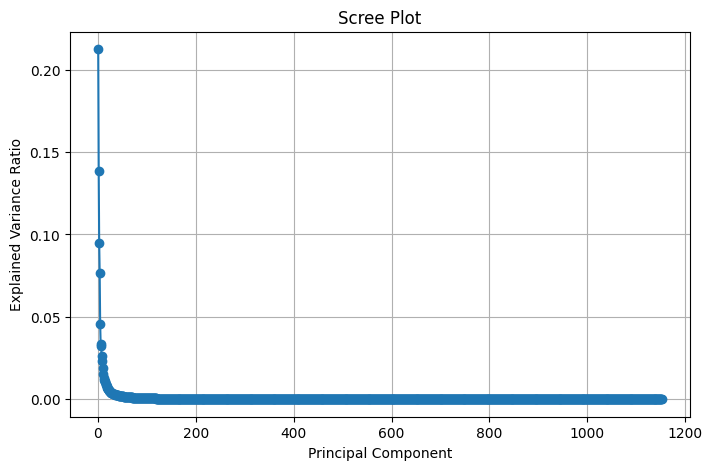

In [7]:
import matplotlib.pyplot as plt

explained = pca.explained_variance_ratio_

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(explained) + 1), explained, marker='o')
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Scree Plot")
plt.grid(True)
plt.show()

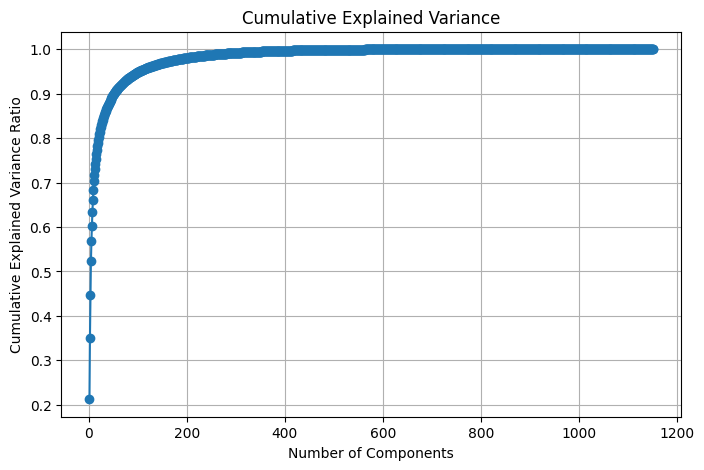

In [8]:
cum_explained = np.cumsum(explained)

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cum_explained) + 1), cum_explained, marker='o')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance Ratio")
plt.title("Cumulative Explained Variance")
plt.grid(True)
plt.show()

In [9]:
k80 = np.argmax(cum_explained >= 0.80) + 1
k90 = np.argmax(cum_explained >= 0.90) + 1
k95 = np.argmax(cum_explained >= 0.95) + 1

print(f"80%:{k80}\n90%:{k90}\n95%:{k95}")

80%:20
90%:52
95%:103


In [10]:
import numpy as np

keys = sorted(
    data.keys(), 
    key=lambda k: (int(k.split('_')[0]), k.split('_')[1]))

patient_ids = []
eyes = []
views = []

for k in keys:
    pid, suffix = k.split("_")
    eye = suffix[0]      # l / r
    view = suffix[1]     # 1 / 2

    patient_ids.append(int(pid))
    eyes.append(eye)
    views.append(int(view))

patient_ids = np.array(patient_ids)
eyes = np.array(eyes)
views = np.array(views)

print(patient_ids[:10])
print(eyes[:10])
print(views[:10])

[1 1 1 1 2 2 2 2 3 3]
['l' 'l' 'r' 'r' 'l' 'l' 'r' 'r' 'l' 'l']
[1 2 1 2 1 2 1 2 1 2]


PC1: mean_l=0.0222, mean_r=-0.0222, diff=-0.0445
PC2: mean_l=1.2160, mean_r=-1.2160, diff=-2.4319
PC3: mean_l=-0.0405, mean_r=0.0405, diff=0.0811
PC4: mean_l=-0.0432, mean_r=0.0432, diff=0.0864
PC5: mean_l=0.0300, mean_r=-0.0300, diff=-0.0599
PC6: mean_l=0.0107, mean_r=-0.0107, diff=-0.0215
PC7: mean_l=0.0062, mean_r=-0.0062, diff=-0.0124
PC8: mean_l=0.0020, mean_r=-0.0020, diff=-0.0039
PC9: mean_l=0.0283, mean_r=-0.0283, diff=-0.0565
PC10: mean_l=-0.0124, mean_r=0.0124, diff=0.0249


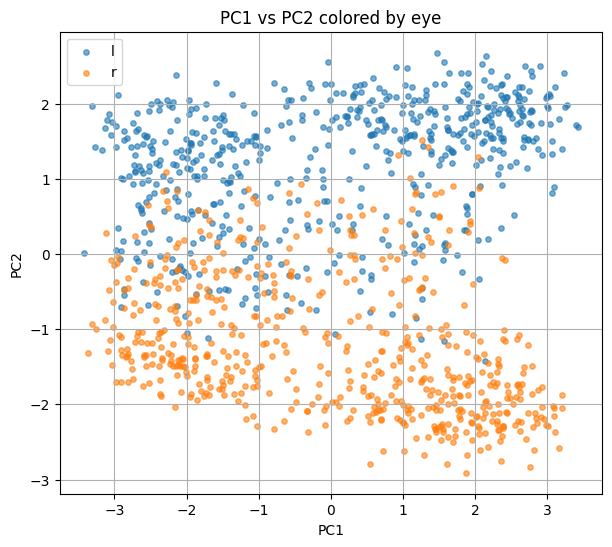

In [ ]:
import matplotlib.pyplot as plt

for i in range(10):
    pc = X_pca[:, i]
    mean_l = pc[eyes == 'l'].mean()
    mean_r = pc[eyes == 'r'].mean()
    print(f"PC{i+1}: mean_l={mean_l:.4f}, mean_r={mean_r:.4f}, diff={mean_r - mean_l:.4f}")



plt.figure(figsize=(7,6))
for e in ['l', 'r']:
    mask = eyes == e
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], s=15, alpha=0.6, label=e)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PC1 vs PC2 colored by eye")
plt.legend()
plt.grid(True)
plt.show()

PC1: mean_v1=-0.0412, mean_v2=0.0412, diff=0.0824
PC2: mean_v1=0.0391, mean_v2=-0.0391, diff=-0.0782
PC3: mean_v1=-0.1735, mean_v2=0.1735, diff=0.3471
PC4: mean_v1=-0.1415, mean_v2=0.1415, diff=0.2830
PC5: mean_v1=-0.4506, mean_v2=0.4506, diff=0.9012
PC6: mean_v1=-0.1989, mean_v2=0.1989, diff=0.3978
PC7: mean_v1=0.1972, mean_v2=-0.1972, diff=-0.3944
PC8: mean_v1=-0.1353, mean_v2=0.1353, diff=0.2705
PC9: mean_v1=-0.0190, mean_v2=0.0190, diff=0.0381
PC10: mean_v1=-0.0449, mean_v2=0.0449, diff=0.0898


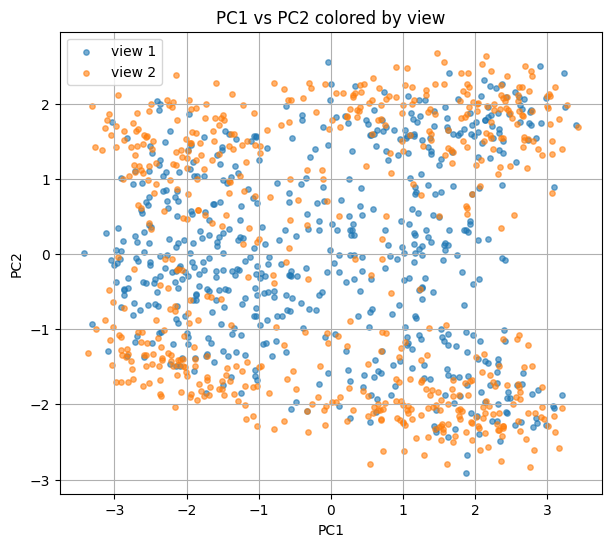

In [12]:
for i in range(10):
    pc = X_pca[:, i]
    mean_v1 = pc[views == 1].mean()
    mean_v2 = pc[views == 2].mean()
    print(f"PC{i+1}: mean_v1={mean_v1:.4f}, mean_v2={mean_v2:.4f}, diff={mean_v2 - mean_v1:.4f}")

plt.figure(figsize=(7,6))
for v in [1, 2]:
    mask = views == v
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], s=15, alpha=0.6, label=f"view {v}")

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PC1 vs PC2 colored by view")
plt.legend()
plt.grid(True)
plt.show()

In [13]:
from scipy.stats import ttest_ind
import numpy as np

for i in range(10):
    pc = X_pca[:, i]
    l_vals = pc[eyes == 'l']
    r_vals = pc[eyes == 'r']

    t_stat, p_val = ttest_ind(l_vals, r_vals, equal_var=False)

    # Cohen's d
    mean_diff = l_vals.mean() - r_vals.mean()
    pooled_std = np.sqrt((l_vals.std(ddof=1)**2 + r_vals.std(ddof=1)**2) / 2)
    cohen_d = mean_diff / pooled_std

    print(f"PC{i+1}: p={p_val:.3e}, Cohen's d={cohen_d:.4f}")

PC1: p=6.802e-01, Cohen's d=0.0240
PC2: p=0.000e+00, Cohen's d=2.7684
PC3: p=2.606e-01, Cohen's d=-0.0654
PC4: p=1.832e-01, Cohen's d=-0.0774
PC5: p=2.321e-01, Cohen's d=0.0695
PC6: p=6.167e-01, Cohen's d=0.0291
PC7: p=7.679e-01, Cohen's d=0.0172
PC8: p=9.178e-01, Cohen's d=0.0060
PC9: p=1.130e-01, Cohen's d=0.0922
PC10: p=4.431e-01, Cohen's d=-0.0446


In [14]:
for i in range(10):
    pc = X_pca[:, i]
    v1_vals = pc[views == 1]
    v2_vals = pc[views == 2]

    t_stat, p_val = ttest_ind(v1_vals, v2_vals, equal_var=False)

    mean_diff = v1_vals.mean() - v2_vals.mean()
    pooled_std = np.sqrt((v1_vals.std(ddof=1)**2 + v2_vals.std(ddof=1)**2) / 2)
    cohen_d = mean_diff / pooled_std

    print(f"PC{i+1}: p={p_val:.3e}, Cohen's d={cohen_d:.4f}")

PC1: p=4.455e-01, Cohen's d=-0.0444
PC2: p=3.701e-01, Cohen's d=0.0521
PC3: p=1.320e-06, Cohen's d=-0.2826
PC4: p=1.203e-05, Cohen's d=-0.2555
PC5: p=0.000e+00, Cohen's d=-1.2249
PC6: p=3.170e-21, Cohen's d=-0.5604
PC7: p=9.584e-22, Cohen's d=0.5680
PC8: p=5.488e-13, Cohen's d=-0.4240
PC9: p=2.855e-01, Cohen's d=-0.0621
PC10: p=5.585e-03, Cohen's d=-0.1614
